#Data cleaning and basic visualization
##Titanic data set analysis

###Interships task - week 1.

**Name:** Moeez Nasir.

**Intership:** Data science & analytics at vortex tech .

In [1]:
# first we import important libraries.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# pandas(pd) : is use to load , clean and analyze data.
# numpy(np)  : it helps with the numerical operation.
# matplotlib.pyplot(plt): it is use to create charts and graphs.


In [2]:
# now we are going to load our data set
df = pd.read_csv("/content/Titanic-Dataset.csv")


In [3]:
df.head() # this shows the first 5 rows of our data set.

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.shape # this tell the number or rows and columns in data set

(891, 12)

In [5]:
df.info() # get information about the data set

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
df.describe() # this gives the statistic summary of your numerical summary.

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [7]:
df.isnull().sum() # checking missing values

# from this we figure out that we have missing values
# 1-Age has 177 missing values
# 2-cabin has 687 missing values
# 3-Embarked has 2 missing values

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [8]:
# now we are going to fill the values

# fill missing values in the age using median.
df["Age"]=df["Age"].fillna(df["Age"].median)
# we use median because it's less affected by the extream values than the mean .

# fill missing values in the Embarked with the most common values.
df["Embarked"]=df['Embarked'].fillna(df["Embarked"].mode()[0])
# we fill the missing values in embarked with the most frequent port.

# since the cabin has two many missing values so we removed it.
df=df.drop(columns=['Cabin'])
# 77% of it's values are missing so we removed it for the beginner project







In [9]:
# now we check for the duplicates rows
df.duplicated().sum() # its give np.int64(0) its mean we don't have a duplicate value

# but what if we have a duplicate value than we drop duplicate row by :
# df = df.drop_duplicates()

np.int64(0)

In [10]:
# now we are varifying the data agian
df.info()
# no missing values in age.
# no missing values in the Embarked .
# cabin row are removed.
# now the data is clean and ready for visualization .


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    object 
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Embarked     891 non-null    object 
dtypes: float64(1), int64(5), object(5)
memory usage: 76.7+ KB


In [11]:
type(df["Age"][5]) # we noticed that the age has tha data type "object" it should be "float" we need to convert it .

method

In [12]:
# First, coerce 'Age' to numeric, converting any non-numeric values (like method objects) to NaN
df["Age"] = pd.to_numeric(df["Age"], errors='coerce')

# Now, fill the actual NaN values with the median of the numeric 'Age' column
df["Age"] = df["Age"].fillna(df["Age"].median())

# Finally, convert the entire column to float type
df["Age"] = df["Age"].astype(float)

print("The 'Age' column has been successfully converted to float. Its new data type is:")
print(df['Age'].dtype)
print("Number of NaN values in 'Age' after correction:", df['Age'].isnull().sum())

The 'Age' column has been successfully converted to float. Its new data type is:
float64
Number of NaN values in 'Age' after correction: 0


### now we steped into the data visualization.

In [13]:
# firstly import libraries
import matplotlib.pyplot as plt
import seaborn as sns

# matplotlib.pyplot(plt) : is use to creat charts and graphs
# seaborn(sns)           : it make those graph much prettier and easy

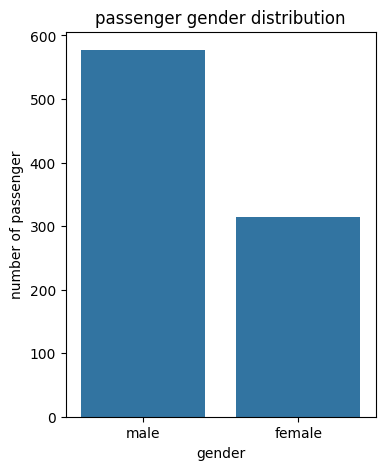

In [20]:
# visualization of the passenger gender distribution.
plt.figure(figsize=(4,5))# this determines the witdh and size of the chart
sns.countplot(data=df,x="Sex")# and countplot count
plt.title("passenger gender distribution")# it give the title to the chart.
plt.xlabel("gender") # this label the x-axis
plt.ylabel("number of passenger")# this label the y-axis
plt.show()

## Visualization 1: Passenger Gender Distribution

This bar chart shows the number of male and female passengers on the Titanic.

**Why this chart?**
A bar chart (countplot) is the best choice for categorical data because it counts the number of occurrences in each category.

**Observation:**
The chart shows that there were more male passengers than female passengers on the Titanic.

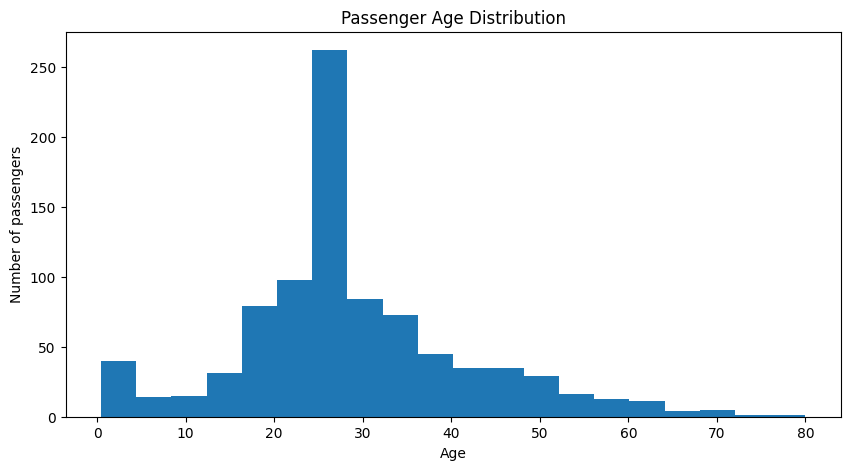

In [36]:
# visualization of the passenger age distribution.
plt.figure(figsize=(10,5))# width and hight of the chart
plt.hist(df["Age"],bins=20)# hist take numerical data divide into groups called bins and count how many values fall into group and draw a bar
plt.title("Passenger Age Distribution")# title of the chart
plt.xlabel("Age")# tell the group of ages
plt.ylabel("Number of passengers")# tell the number of people lies in the specific group
plt.show()# use to show graph

## Visualization 2: Age Distribution

This histogram shows the distribution of passengers' ages.

**Why this chart?**
A histogram is used because Age is numerical data. It groups ages into ranges (bins) and shows how many passengers fall into each range.

**Observation:**
Most passengers were young adults, with a large number of passengers between approximately 20 and 40 years of age.

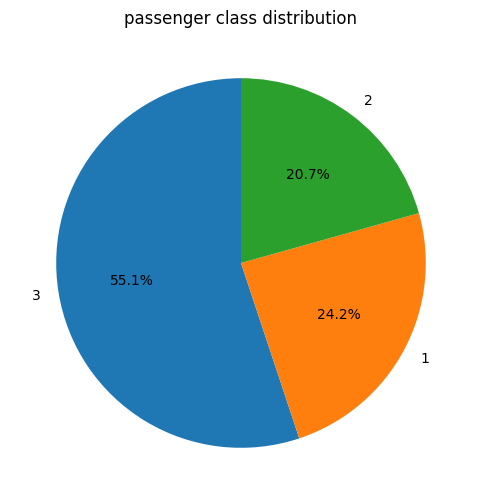

In [56]:
# now we creat the pie chart visualization
# we want to find the number of passenger travel in the first, second and third class (Pclass)
class_counts = df["Pclass"].value_counts()# this count the number of passenger in different classes and store in it variable
plt.figure(figsize=(6,6))# ----------------because pichart is a circle so figsize= always equal to make perfect circle .
plt.pie(class_counts # --------------------is the variable where distribution data (passenger is class) is stored
        labels=class_counts.index,#------- is give the number to each part
        autopct="%1.1f%%",# ---------------it gives the exact percentage of the each part
        startangle=90 # -------------------piechart usually start from 0 degree angle so make is much profession we start it from 90 degree angle
        )
plt.title("passenger class distribution")
plt.show()

## Visualization 3: Passenger Class Distribution

This pie chart shows the percentage of passengers traveling in First, Second, and Third Class.

**Why this chart?**
A pie chart is useful for showing the proportion or percentage that each passenger class contributes to the whole dataset.

**Observation:**
The largest percentage of passengers traveled in Third Class, while First and Second Class had smaller proportions.

<function matplotlib.pyplot.show(close=None, block=None)>

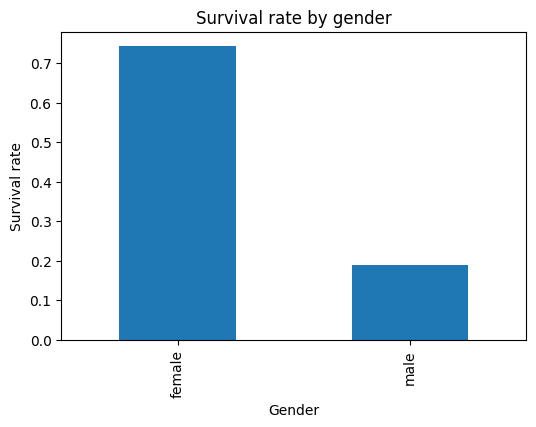

In [59]:
# new we clasify the gender survival rate
survival_by_gender = df.groupby("Sex")['Survived'].mean()# this make two group (male,female) and calculate the survival rate
plt.figure(figsize=(6,4))
survival_by_gender.plot(kind='bar')
plt.title('Survival rate by gender')
plt.xlabel("Gender")
plt.ylabel("Survival rate")
plt.show

## Visualization 4: Survival Rate by Gender

This bar chart compares the average survival rate of male and female passengers.

**Why this chart?**
A bar chart makes it easy to compare the survival rates of different gender groups.

**Observation:**
Female passengers had a significantly higher survival rate than male passengers, indicating that women were more likely to survive the Titanic disaster.

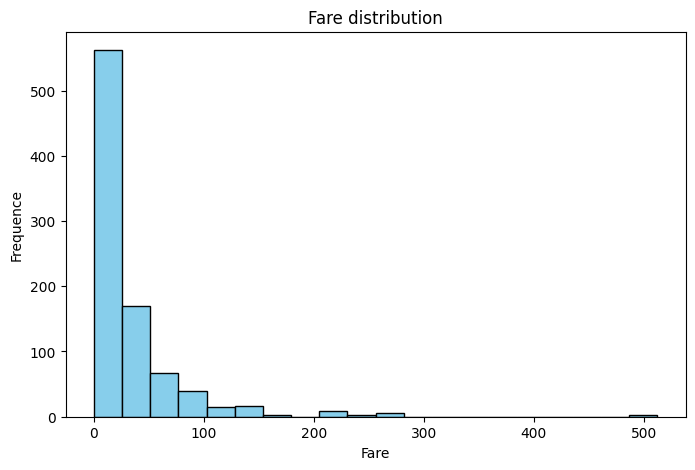

In [63]:
# fare distribution by histogram
plt.figure(figsize=(8,5))
plt.hist(df['Fare'],bins=20,color='skyblue',edgecolor='black')
plt.title("Fare distribution")
plt.xlabel("Fare")
plt.ylabel("Frequence")
plt.show()


## Visualization 5: Fare Distribution

This histogram shows the distribution of ticket fares paid by passengers.

**Why this chart?**
A histogram is appropriate because Fare is numerical data. It groups fare values into ranges and displays the frequency of passengers within each range.

**Observation:**
Most passengers paid lower fares, while only a small number of passengers paid very high fares.

# Conclusion

In this project, I analyzed the Titanic dataset using Python, Pandas, Matplotlib, and Seaborn.

I explored the dataset, handled missing values, removed unnecessary data, and created different visualizations to better understand passenger demographics and survival patterns.

### Key Findings

- There were more male passengers than female passengers.
- Most passengers were between 20 and 40 years old.
- Third Class had the highest number of passengers.
- Female passengers had a much higher survival rate than male passengers.
- Most passengers paid relatively low ticket fares.

This project helped me practice data cleaning, exploratory data analysis (EDA), and data visualization using Python.